In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
import seaborn as sns
from scipy import stats as scipystats

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 800)
pd.set_option('display.precision', 3)
pd.set_option('display.expand_frame_repr', False)

sys.path.insert(0, r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter")
from core import annotate_significance_vs_ref
import importlib
importlib.reload(sys.modules["core"])

<module 'core' from 'C:\\Users\\timon\\OneDrive\\Helmholtz\\Scripts\\Yagya_jupyter\\core.py'>

# ***import dataprep files from both reps and concatenate*** 

In [ ]:
rep1 = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\smFISH_rep1_postAnalysis.csv")
rep2 = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\smFISH_rep2_postAnalysis.csv")
granddata = pd.concat([rep1, rep2])
granddata = granddata.reset_index(drop = True)

# ***Fig_S1: plotting mean WHI5 mRNA count per cell for all cell cycle stages*** 


Group: 'Strain'  |  Value: 'num_spots'


,Strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,WT,395,1.2,1.0,1.50,3,Shapiro-Wilk,0.0,False
1,Bck2 del,585,1.2,1.0,1.04,2,Shapiro-Wilk,0.0,False
2,Ccr4 del,340,0.8,0.0,1.78,29,Shapiro-Wilk,0.0,False
3,Whi5 del,446,0.1,0.0,4.22,30,Shapiro-Wilk,0.0,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05)
0,WT vs Bck2 del,395,585,0.602,0.602,0.577,False,False,False
1,WT vs Ccr4 del,395,340,0.000,0.000,0.000,True,True,True
2,WT vs Whi5 del,395,446,0.000,0.000,0.000,True,True,True
3,Bck2 del vs Ccr4 del,585,340,0.000,0.000,0.000,True,True,True
4,Bck2 del vs Whi5 del,585,446,0.000,0.000,0.000,True,True,True
5,Ccr4 del vs Whi5 del,340,446,0.000,0.000,0.000,True,True,True


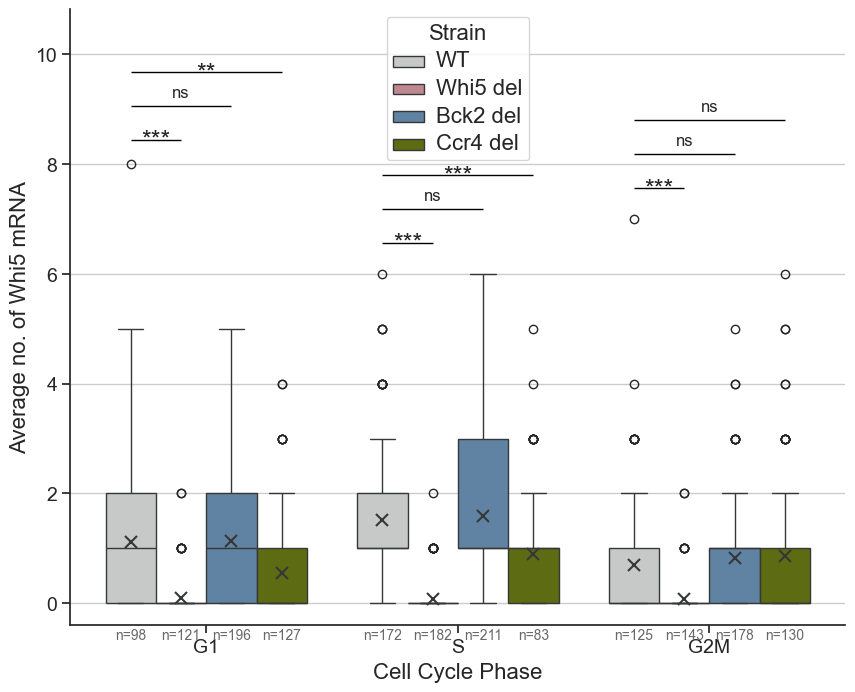

In [14]:
import core


sns.set_context("notebook", rc={"lines.linewidth": 1.5})
sns.set_style("ticks",{'axes.grid' : True})

PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
palette ={"WT":"#c5c9c7" , "Whi5 del": "#c87f89", "Bck2 del": "#5684ae", "Ccr4 del":"#677a04"}
p,(ax17) = plt.subplots(nrows = 1, ncols = 1, figsize = (10,8))

p = sns.boxplot(x="phase_yc", y="num_spots", order = ["G1","S", "G2M"],
            hue="Strain", data=granddata, ax=ax17, palette = palette, showmeans = True,
            hue_order = ["WT", "Whi5 del","Bck2 del", "Ccr4 del"],
            meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"8",
                      "markeredgewidth": 1.5},
                **PROPS)
#ax17.set_ylim(0, 8)
p.set_xlabel("Cell Cycle Phase", fontsize=16)
p.set_ylabel("Average no. of Whi5 mRNA", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.setp(p.get_legend().get_texts(), fontsize='16')
plt.setp(p.get_legend().get_title(), fontsize='16')

ax17.spines['right'].set_visible(False)
ax17.spines['top'].set_visible(False)

core.run_stats(
    granddata,
    value_cols="num_spots",
    group_col="Strain"
)
core.annotate_significance_hue_vs_ref(
    ax=ax17,
    df=granddata,
    x_col="phase_yc",
    hue_col="Strain",
    y_col="num_spots",
    x_order=["G1","S", "G2M"],
    hue_order=["WT", "Whi5 del","Bck2 del", "Ccr4 del"],
    ref_hue="WT",
    test="mwu"
)

#save figure
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\supplement\Fig2\smFISH_Whi5_allCCstages.svg", dpi =150)
plt.show()

# ***Fig_S1: printing cell numbers in each category and statistics (independent two-tailed t-test unequal variances)*** 

In [6]:
print("spots stats S phase:")
WT_df = granddata[(granddata["Strain"] == "WT") & (granddata["phase_yc"] == "S") ]
whi5del_df =  granddata[(granddata["Strain"] == "Whi5 del") & (granddata["phase_yc"] == "S")]
bck2del_df = granddata[(granddata["Strain"] == "Bck2 del") & (granddata["phase_yc"] == "S") ]
ccr4del_df = granddata[(granddata["Strain"] == "Ccr4 del") & (granddata["phase_yc"] == "S") ]

print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("ccr4del n", len(ccr4del_df))


print("WT VS BCK2",scipystats.ttest_ind((WT_df["num_spots"]), (bck2del_df["num_spots"]), equal_var = False))
print("WT VS CCR4",scipystats.ttest_ind((WT_df["num_spots"]), (ccr4del_df["num_spots"]), equal_var = False))
print("WT VS WHI5",scipystats.ttest_ind((WT_df["num_spots"]), (whi5del_df["num_spots"]), equal_var = False))

print("spots stats G1 phase:")
WT_df = granddata[(granddata["Strain"] == "WT") & (granddata["phase_yc"] == "G1") ]
whi5del_df =  granddata[(granddata["Strain"] == "Whi5 del") & (granddata["phase_yc"] == "G1")]
bck2del_df = granddata[(granddata["Strain"] == "Bck2 del") & (granddata["phase_yc"] == "G1") ]
ccr4del_df = granddata[(granddata["Strain"] == "Ccr4 del") & (granddata["phase_yc"] == "G1") ]

print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("ccr4del n", len(ccr4del_df))

print("spots stats G2M phase:")
WT_df = granddata[(granddata["Strain"] == "WT") & (granddata["phase_yc"] == "G2M") ]
whi5del_df =  granddata[(granddata["Strain"] == "Whi5 del") & (granddata["phase_yc"] == "G2M")]
bck2del_df = granddata[(granddata["Strain"] == "Bck2 del") & (granddata["phase_yc"] == "G2M") ]
ccr4del_df = granddata[(granddata["Strain"] == "Ccr4 del") & (granddata["phase_yc"] == "G2M") ]

print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("ccr4del n", len(ccr4del_df))

spots stats S phase:
WT n 172
Bck2del n 211
whi5del n 182
ccr4del n 83
WT VS BCK2 TtestResult(statistic=np.float64(-0.5337608651738209), pvalue=np.float64(0.5938220906632306), df=np.float64(376.35778367063983))
WT VS CCR4 TtestResult(statistic=np.float64(4.056251280434269), pvalue=np.float64(7.503748860097407e-05), df=np.float64(174.73369905253796))
WT VS WHI5 TtestResult(statistic=np.float64(15.317522984378229), pvalue=np.float64(5.617367963143559e-35), df=np.float64(189.2847754886712))
spots stats G1 phase:
WT n 98
Bck2del n 196
whi5del n 121
ccr4del n 127
spots stats G2M phase:
WT n 125
Bck2del n 178
whi5del n 143
ccr4del n 130


# ***Fig_1C: plotting mean WHI5 mRNA count per cell for S-phase cells only*** 


Group: 'Strain'  |  Value: 'num_spots'


C:\Users\timon\AppData\Local\Temp\ipykernel_3392\1025338198.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  p = sns.boxplot(x="Strain",


,Strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,WT,172,1.5,1.0,0.94,11,Shapiro-Wilk,1.000e-10,False
1,Bck2 del,211,1.6,1.0,0.65,0,Shapiro-Wilk,1.000e-10,False
2,Ccr4 del,83,0.9,1.0,1.37,10,Shapiro-Wilk,5.000e-10,False
3,Whi5 del,182,0.1,0.0,3.86,13,Shapiro-Wilk,0.000e+00,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05)
0,WT vs Bck2 del,172,211,5.938e-01,5.973e-01,0.724,False,False,False
1,WT vs Ccr4 del,172,83,1.000e-04,1.000e-04,0.000,True,True,True
2,WT vs Whi5 del,172,182,0.000e+00,0.000e+00,0.000,True,True,True
3,Bck2 del vs Ccr4 del,211,83,0.000e+00,0.000e+00,0.000,True,True,True
4,Bck2 del vs Whi5 del,211,182,0.000e+00,0.000e+00,0.000,True,True,True
5,Ccr4 del vs Whi5 del,83,182,0.000e+00,0.000e+00,0.000,True,True,True


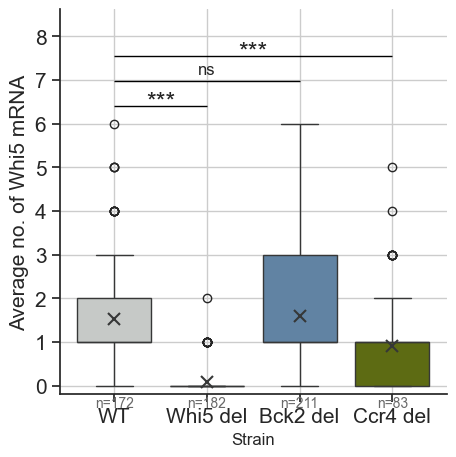

In [11]:
import core


sns.set_context("notebook", rc={"lines.linewidth": 1.5})
sns.set_style("ticks")

PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}

p,(ax17) = plt.subplots(nrows = 1, ncols = 1, figsize = (5,5))
palette ={"WT":"#c5c9c7" , "Whi5 del": "#c87f89", "Bck2 del": "#5684ae", "Ccr4 del":"#677a04"}
p = sns.boxplot(x="Strain", 
                y="num_spots",
                order = ["WT", "Whi5 del","Bck2 del", "Ccr4 del"],
                # hue_order = ["WT", "Whi5 del","Bck2 del", "Ccr4 del"], 
                # #width = 0.5,
                # hue="Strain",
                showmeans = True,
                data=granddata[granddata['phase_yc'] == "S"], 
                ax=ax17, 
                palette = palette, 
                
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"8",
                      "markeredgewidth": 1.5},
                **PROPS
                #edgecolor = "#363737", 
                #errorbar=('ci', 68)
               )


ax17.set_ylim(-0.2, 8)
ax17.spines['right'].set_visible(False)
ax17.spines['top'].set_visible(False)
#p.set_xlabel("", fontsize=15)
p.set_ylabel("Average no. of Whi5 mRNA", fontsize=15)
#plt.xticks([],fontsize=14)
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
#ax17.legend(bbox_to_anchor=(1.3, 1.05))
ax17.grid()


core.run_stats(
    granddata[granddata['phase_yc'] == "S"],
    value_cols="num_spots",
    group_col="Strain"
)

core.annotate_significance_vs_ref(
    ax=ax17,
    df=granddata[granddata['phase_yc'] == "S"],
    x_col="Strain",
    y_col="num_spots",
    x_order=["WT", "Whi5 del","Bck2 del", "Ccr4 del"],
    ref_group="WT",
    test="mwu"
)


#save figure
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig1\panel3.svg", dpi =150)
plt.show()